# Expected Shortfall (CVaR)

This notebook demonstrates Expected Shortfall (ES), also called Conditional Value-at-Risk (CVaR).

VaR gives the minimum expected loss at a given confidence level (e.g. 95%), ES gives the average loss in the worst 5% of cases. 

Included:
1. Load asset returns
2. Compute Historical VaR
3. Compute Historical ES
4. Compare the two measures

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from src.var_methods import historical_var
from src.es_methods import historical_es

## Load Data
Using the same SPY ETF example as in the previous notebook for a direct comparison.

In [24]:
ticker = "SPY"
data = pd.read_csv(
    "../data/sample_prices.csv",
    index_col=0,
    parse_dates=[0],
    date_parser=lambda x: pd.to_datetime(x, format="%d/%m/%Y")
)
log_returns = np.log(data / data.shift(1)).dropna()

log_returns.head()

,BND,GLD,QQQ,SPY
Date,,,,
2020-01-03,0.003566,0.013181,-0.009202,-0.007601
2020-01-06,-0.001187,0.010435,0.006423,0.003808
2020-01-07,-0.000832,0.003927,-0.000139,-0.002816
2020-01-08,-0.001547,-0.007530,0.007488,0.005315
2020-01-09,0.001190,-0.005668,0.008438,0.006758


## Historical VaR vs. ES

- We assume a portfolio value of **$1,000,000**
- Significance level **alpha = 0.05** (95% confidence)
- Again only one asset in the "portfolio" so its weighting is 1
- The ES can be significantly higher than the VaR (especially in portfolios with fat tails)

In [25]:
weights = np.array([1])
portfolio_value = 1_000_000
alpha = 0.05

hist_var = historical_var(log_returns["SPY"], alpha=alpha, portfolio_value=portfolio_value, weights=weights)
hist_es = historical_es(log_returns[["SPY"]], weights=weights, alpha=alpha, portfolio_value=portfolio_value)

print("Historical 95% 1-day VaR: $" + str(int(hist_var)))
print("Historical 95% 1-day ES:  $" + str(int(hist_es)))

Historical 95% 1-day VaR: $19441
Historical 95% 1-day ES:  $32625


## Visualization
- Highlighted are the VaR cutoff (red dashed line) and the tail region used for ES (shaded area)
- For portfolio's with other elements the plot would include the weighted log return for every asset



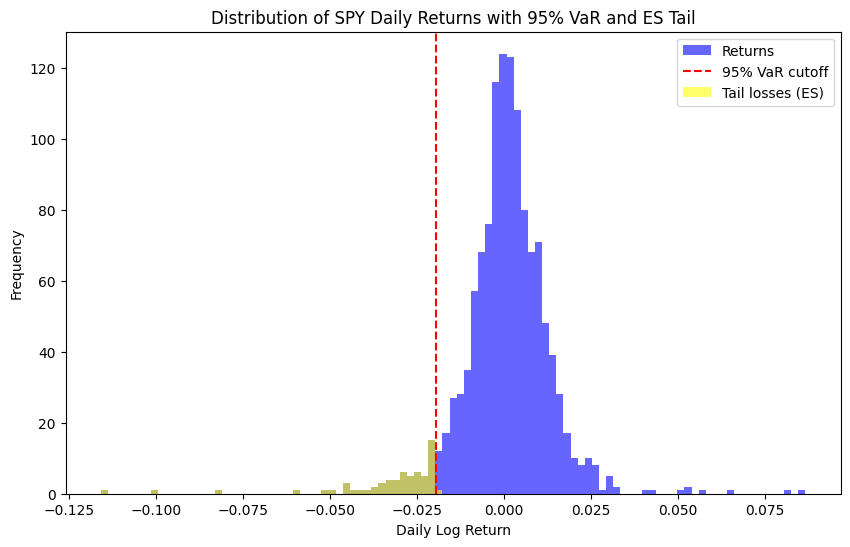

In [27]:
spy_returns = log_returns["SPY"]

cutoff = np.percentile(spy_returns.values, alpha*100)
tail_losses = spy_returns[spy_returns <= cutoff]

bins = np.linspace(spy_returns.min(), spy_returns.max(), 100)

plt.figure(figsize=(10,6))
plt.hist(spy_returns, bins=bins, alpha=0.6, label="Returns", color="blue")
plt.axvline(cutoff, color="red", linestyle="--", label="95% VaR cutoff")
plt.hist(tail_losses, bins=bins, alpha=0.6, color="yellow", label="Tail losses (ES)")
plt.title("Distribution of SPY Daily Returns with 95% VaR and ES Tail")
plt.xlabel("Daily Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Summary

- Historical VaR gives the threshold loss exceeded on 5% of days.
- Historical ES (CVaR) gives the average loss on those worst 5% of days.
- ES is considered a more robust and coherent risk measure, since it accounts for tail loss-severity, not just frequency.